# User-to-Item Model Metrics
We decided to interpret the metrics of the user-to-item recsys inside of one notebook in order to be able to compare them among each other.

We normalized all of the results in order to properly compare them.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [10]:
RESULTS_DIR = Path("../data/results")
summary_paths = sorted(RESULTS_DIR.glob("*_summary.csv"))

summary_paths

[WindowsPath('../data/results/bert_summary.csv'),
 WindowsPath('../data/results/bow_summary.csv'),
 WindowsPath('../data/results/lemma_summary.csv'),
 WindowsPath('../data/results/ner_summary.csv'),
 WindowsPath('../data/results/tfidf_summary.csv')]

In [11]:
def load_summary(path: Path) -> pd.Series:
    df = pd.read_csv(path, index_col=0)

    if df.shape[1] == 1:
        series = df.iloc[:, 0]
        series.name = df.columns[0]
        return pd.to_numeric(series, errors="coerce")

    if df.shape[0] == 1:
        series = df.iloc[0]
        if "model" in df.columns:
            series = series.drop(labels=["model"])
            series.name = df.iloc[0]["model"]
        else:
            series.name = path.stem.replace("_summary", "")
        return pd.to_numeric(series, errors="coerce")

    raise ValueError(f"Unsupported summary format: {path}")


summary_series = [load_summary(path) for path in summary_paths]
comparison_df = pd.concat(summary_series, axis=1).T
comparison_df.index.name = "Model"
comparison_df = comparison_df.sort_index()

comparison_df.round(4)

,Precision@5,Recall@5,NDCG@5,MAP@5,HitRate@5,MRR@5,Precision@10,Recall@10,NDCG@10,MAP@10,HitRate@10,MRR@10,Precision@20,Recall@20,NDCG@20,MAP@20,HitRate@20,MRR@20
Model,,,,,,,,,,,,,,,,,,
BERT,0.0008,0.0015,0.0011,0.0006,0.0038,0.0016,0.0008,0.0031,0.0018,0.0008,0.0084,0.0022,0.0007,0.0056,0.0025,0.0010,0.0144,0.0026
BoW,0.0030,0.0045,0.0042,0.0024,NaN,NaN,0.0021,0.0061,0.0047,0.0024,NaN,NaN,0.0016,0.0096,0.0058,0.0026,NaN,NaN
Lemma TF-IDF,0.0019,0.0035,0.0029,0.0018,0.0088,0.0043,0.0014,0.0055,0.0036,0.0020,0.0132,0.0049,0.0010,0.0071,0.0042,0.0021,0.0184,0.0052
NER TF-IDF,0.0009,0.0016,0.0013,0.0008,0.0046,0.0020,0.0008,0.0025,0.0017,0.0008,0.0080,0.0024,0.0009,0.0057,0.0028,0.0011,0.0178,0.0031
TF-IDF,0.0042,0.0075,0.0069,0.0044,NaN,NaN,0.0037,0.0123,0.0088,0.0049,NaN,NaN,0.0027,0.0184,0.0107,0.0053,NaN,NaN


In [12]:
common_metrics = comparison_df.columns[comparison_df.notna().all()].tolist()
common_df = comparison_df[common_metrics].copy()

preferred_order = [
    "Precision@5", "Recall@5", "NDCG@5", "MAP@5",
    "Precision@10", "Recall@10", "NDCG@10", "MAP@10",
    "Precision@20", "Recall@20", "NDCG@20", "MAP@20"
]
ordered_common_metrics = [metric for metric in preferred_order if metric in common_df.columns]
common_df = common_df[ordered_common_metrics]

common_df.round(4)

,Precision@5,Recall@5,NDCG@5,MAP@5,Precision@10,Recall@10,NDCG@10,MAP@10,Precision@20,Recall@20,NDCG@20,MAP@20
Model,,,,,,,,,,,,
BERT,0.0008,0.0015,0.0011,0.0006,0.0008,0.0031,0.0018,0.0008,0.0007,0.0056,0.0025,0.0010
BoW,0.0030,0.0045,0.0042,0.0024,0.0021,0.0061,0.0047,0.0024,0.0016,0.0096,0.0058,0.0026
Lemma TF-IDF,0.0019,0.0035,0.0029,0.0018,0.0014,0.0055,0.0036,0.0020,0.0010,0.0071,0.0042,0.0021
NER TF-IDF,0.0009,0.0016,0.0013,0.0008,0.0008,0.0025,0.0017,0.0008,0.0009,0.0057,0.0028,0.0011
TF-IDF,0.0042,0.0075,0.0069,0.0044,0.0037,0.0123,0.0088,0.0049,0.0027,0.0184,0.0107,0.0053


We created a ranking of the models for each of the metrics, which include:
- NDCG@10 (how well the model ranks the recommendations, more credit when relevant wines appear higher up) -> how well did we order the results?
- Recall@10 (what fraction of the user's relevant test wines were successfully retrieved within the top 10) -> how much did we manage to find?
- MAP@10 (measures the average precision of the ranked list up to 10) -> how consistently do good results appear?
- Precision@10 (measures what fraction of the 10 wines is actually relevant for the user) -> how accurate is the list?

In [13]:
ranking_metrics = [metric for metric in ["NDCG@10", "Recall@10", "MAP@10", "Precision@10"] if metric in common_df.columns]

for metric in ranking_metrics:
    display(common_df[[metric]].sort_values(metric, ascending=False).round(4))

,NDCG@10
Model,
TF-IDF,0.0088
BoW,0.0047
Lemma TF-IDF,0.0036
BERT,0.0018
NER TF-IDF,0.0017


,Recall@10
Model,
TF-IDF,0.0123
BoW,0.0061
Lemma TF-IDF,0.0055
BERT,0.0031
NER TF-IDF,0.0025


,MAP@10
Model,
TF-IDF,0.0049
BoW,0.0024
Lemma TF-IDF,0.0020
BERT,0.0008
NER TF-IDF,0.0008


,Precision@10
Model,
TF-IDF,0.0037
BoW,0.0021
Lemma TF-IDF,0.0014
BERT,0.0008
NER TF-IDF,0.0008


To better understand the results, we plotted them:

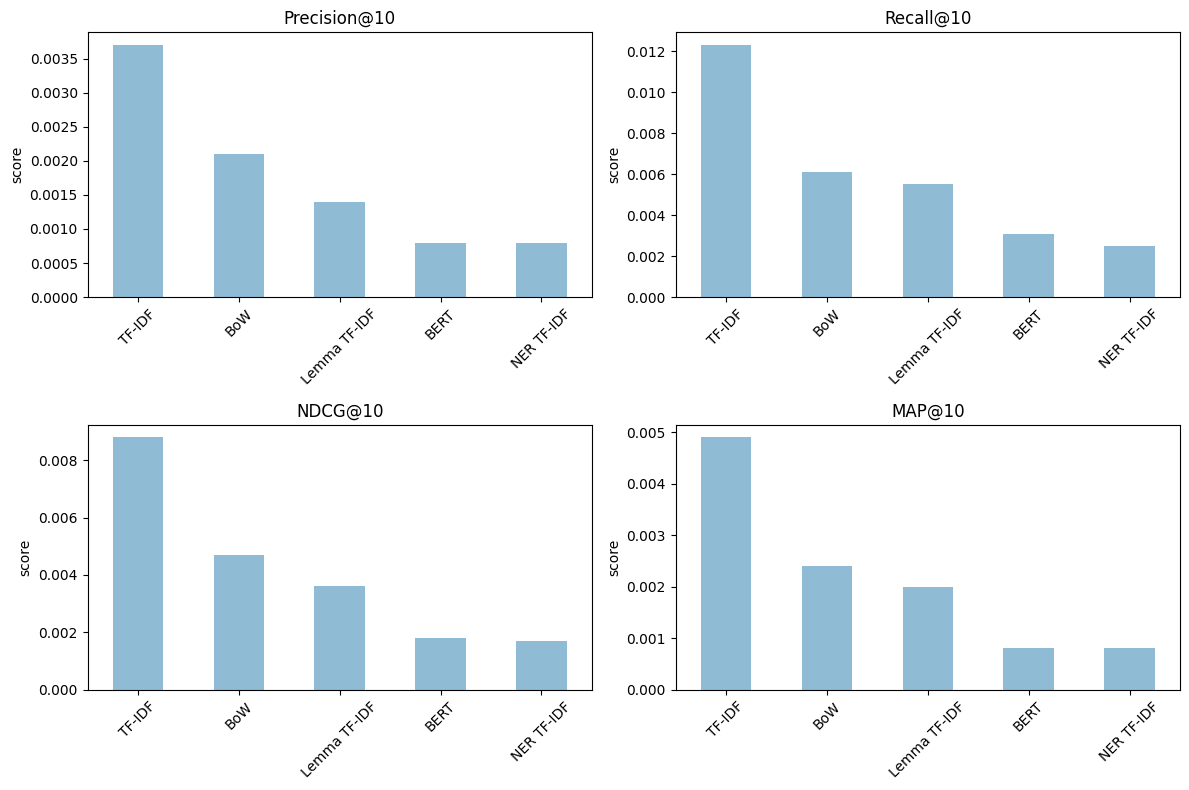

In [14]:
plot_metrics = [metric for metric in ["Precision@10", "Recall@10", "NDCG@10", "MAP@10"] if metric in common_df.columns]

if plot_metrics:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, metric in zip(axes, plot_metrics):
        common_df[metric].sort_values(ascending=False).plot(kind="bar", ax=ax, color="#8fbcd4")
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("score")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(plot_metrics):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [15]:
comparison_export = comparison_df.reset_index()
comparison_export.to_csv(RESULTS_DIR / "all_model_summaries_comparison.csv", index=False)

comparison_export.head()

,Model,Precision@5,Recall@5,NDCG@5,MAP@5,HitRate@5,MRR@5,Precision@10,Recall@10,NDCG@10,MAP@10,HitRate@10,MRR@10,Precision@20,Recall@20,NDCG@20,MAP@20,HitRate@20,MRR@20
0,BERT,0.0008,0.0015,0.0011,0.0006,0.0038,0.0016,0.0008,0.0031,0.0018,0.0008,0.0084,0.0022,0.0007,0.0056,0.0025,0.0010,0.0144,0.0026
1,BoW,0.0030,0.0045,0.0042,0.0024,NaN,NaN,0.0021,0.0061,0.0047,0.0024,NaN,NaN,0.0016,0.0096,0.0058,0.0026,NaN,NaN
2,Lemma TF-IDF,0.0019,0.0035,0.0029,0.0018,0.0088,0.0043,0.0014,0.0055,0.0036,0.0020,0.0132,0.0049,0.0010,0.0071,0.0042,0.0021,0.0184,0.0052
3,NER TF-IDF,0.0009,0.0016,0.0013,0.0008,0.0046,0.0020,0.0008,0.0025,0.0017,0.0008,0.0080,0.0024,0.0009,0.0057,0.0028,0.0011,0.0178,0.0031
4,TF-IDF,0.0042,0.0075,0.0069,0.0044,NaN,NaN,0.0037,0.0123,0.0088,0.0049,NaN,NaN,0.0027,0.0184,0.0107,0.0053,NaN,NaN


TF-IDF seems to be the strongest model among the five on all top-10 ranking metrics meaning that it contains the highest share of relevant wines and ranks them better. Bag-of-Words seems to perform the second best, indicating that simple lexical models perform well here. Lemmatization and the use of NER did not improve TF-IDF's performance, quite the opposite. The metrics overall seem to be very very bad, however there are multiple factors causing this. One of them is the large amount of near duplicates (wines with all of the columns being identical except for the WineID), another being the large size of the catalog. That is why we decided to treat the metrics above as 'strict evaluation' and try to perform 'soft evaluation' which will check other metadata for the recommendations.

In [23]:
soft_summary_paths = sorted(RESULTS_DIR.glob("*_summary_soft.csv"))
soft_summary_paths

[WindowsPath('../data/results/bert_summary_soft.csv'),
 WindowsPath('../data/results/bow_summary_soft.csv'),
 WindowsPath('../data/results/lemma_summary_soft.csv'),
 WindowsPath('../data/results/ner_summary_soft.csv'),
 WindowsPath('../data/results/tfidf_summary_soft.csv')]

In [24]:
if soft_summary_paths:
    soft_summary_series = [load_summary(path) for path in soft_summary_paths]
    soft_comparison_df = pd.concat(soft_summary_series, axis=1).T
    soft_comparison_df.index.name = "Model"
    soft_comparison_df = soft_comparison_df.sort_index()
else:
    soft_comparison_df = pd.DataFrame()

soft_comparison_df.round(4)

,Precision@5,Recall@5,NDCG@5,MAP@5,HitRate@5,MRR@5,Precision@10,Recall@10,NDCG@10,MAP@10,HitRate@10,MRR@10,Precision@20,Recall@20,NDCG@20,MAP@20,HitRate@20,MRR@20
Model,,,,,,,,,,,,,,,,,,
BERT Soft,0.0586,0.1132,0.1099,0.0790,0.2536,0.1687,0.0385,0.1458,0.1210,0.0820,0.3158,0.1772,0.0249,0.1820,0.1329,0.0847,0.3894,0.1823
BoW Soft,0.0630,0.1133,0.1217,0.0877,0.2764,0.2035,0.0362,0.1288,0.1242,0.0865,0.3066,0.2075,0.0193,0.1384,0.1263,0.0865,0.3248,0.2088
Lemma TF-IDF Soft,0.0518,0.1022,0.1037,0.0751,0.2346,0.1673,0.0320,0.1245,0.1107,0.0764,0.2826,0.1736,0.0184,0.1391,0.1153,0.0774,0.3146,0.1759
NER TF-IDF Soft,0.0348,0.0699,0.0784,0.0588,0.1658,0.1348,0.0207,0.0816,0.0818,0.0590,0.1958,0.1389,0.0113,0.0863,0.0832,0.0592,0.2112,0.1400
TF-IDF Soft,0.0752,0.1349,0.1338,0.0943,0.3150,0.2099,0.0467,0.1660,0.1425,0.0953,0.3714,0.2175,0.0258,0.1847,0.1475,0.0961,0.4050,0.2200


We normalized all soft-evaluation results in the same way so that the models can be compared directly.

In [25]:
if not soft_comparison_df.empty:
    soft_common_metrics = soft_comparison_df.columns[soft_comparison_df.notna().all()].tolist()
    soft_common_df = soft_comparison_df[soft_common_metrics].copy()

    preferred_order = [
        "Precision@5", "Recall@5", "NDCG@5", "MAP@5",
        "Precision@10", "Recall@10", "NDCG@10", "MAP@10",
        "Precision@20", "Recall@20", "NDCG@20", "MAP@20"
    ]
    ordered_soft_common_metrics = [metric for metric in preferred_order if metric in soft_common_df.columns]
    soft_common_df = soft_common_df[ordered_soft_common_metrics]
else:
    soft_common_df = pd.DataFrame()

soft_common_df.round(4)

,Precision@5,Recall@5,NDCG@5,MAP@5,Precision@10,Recall@10,NDCG@10,MAP@10,Precision@20,Recall@20,NDCG@20,MAP@20
Model,,,,,,,,,,,,
BERT Soft,0.0586,0.1132,0.1099,0.0790,0.0385,0.1458,0.1210,0.0820,0.0249,0.1820,0.1329,0.0847
BoW Soft,0.0630,0.1133,0.1217,0.0877,0.0362,0.1288,0.1242,0.0865,0.0193,0.1384,0.1263,0.0865
Lemma TF-IDF Soft,0.0518,0.1022,0.1037,0.0751,0.0320,0.1245,0.1107,0.0764,0.0184,0.1391,0.1153,0.0774
NER TF-IDF Soft,0.0348,0.0699,0.0784,0.0588,0.0207,0.0816,0.0818,0.0590,0.0113,0.0863,0.0832,0.0592
TF-IDF Soft,0.0752,0.1349,0.1338,0.0943,0.0467,0.1660,0.1425,0.0953,0.0258,0.1847,0.1475,0.0961


In [26]:
if not soft_comparison_df.empty:
    soft_extra_metrics = [metric for metric in soft_comparison_df.columns if metric not in soft_common_df.columns]
    soft_extra_df = soft_comparison_df[soft_extra_metrics].copy() if soft_extra_metrics else pd.DataFrame(index=soft_comparison_df.index)
else:
    soft_extra_df = pd.DataFrame()

soft_extra_df.round(4)

,HitRate@5,MRR@5,HitRate@10,MRR@10,HitRate@20,MRR@20
Model,,,,,,
BERT Soft,0.2536,0.1687,0.3158,0.1772,0.3894,0.1823
BoW Soft,0.2764,0.2035,0.3066,0.2075,0.3248,0.2088
Lemma TF-IDF Soft,0.2346,0.1673,0.2826,0.1736,0.3146,0.1759
NER TF-IDF Soft,0.1658,0.1348,0.1958,0.1389,0.2112,0.1400
TF-IDF Soft,0.3150,0.2099,0.3714,0.2175,0.4050,0.2200


In [27]:
if not soft_common_df.empty:
    soft_ranking_metrics = [metric for metric in ["NDCG@10", "Recall@10", "MAP@10", "Precision@10"] if metric in soft_common_df.columns]
    for metric in soft_ranking_metrics:
        display(soft_common_df[[metric]].sort_values(metric, ascending=False).round(4))
else:
    print("No soft summary files found yet. Run the soft evaluation cells in the user-to-item notebooks first.")

,NDCG@10
Model,
TF-IDF Soft,0.1425
BoW Soft,0.1242
BERT Soft,0.1210
Lemma TF-IDF Soft,0.1107
NER TF-IDF Soft,0.0818


,Recall@10
Model,
TF-IDF Soft,0.1660
BERT Soft,0.1458
BoW Soft,0.1288
Lemma TF-IDF Soft,0.1245
NER TF-IDF Soft,0.0816


,MAP@10
Model,
TF-IDF Soft,0.0953
BoW Soft,0.0865
BERT Soft,0.0820
Lemma TF-IDF Soft,0.0764
NER TF-IDF Soft,0.0590


,Precision@10
Model,
TF-IDF Soft,0.0467
BERT Soft,0.0385
BoW Soft,0.0362
Lemma TF-IDF Soft,0.0320
NER TF-IDF Soft,0.0207


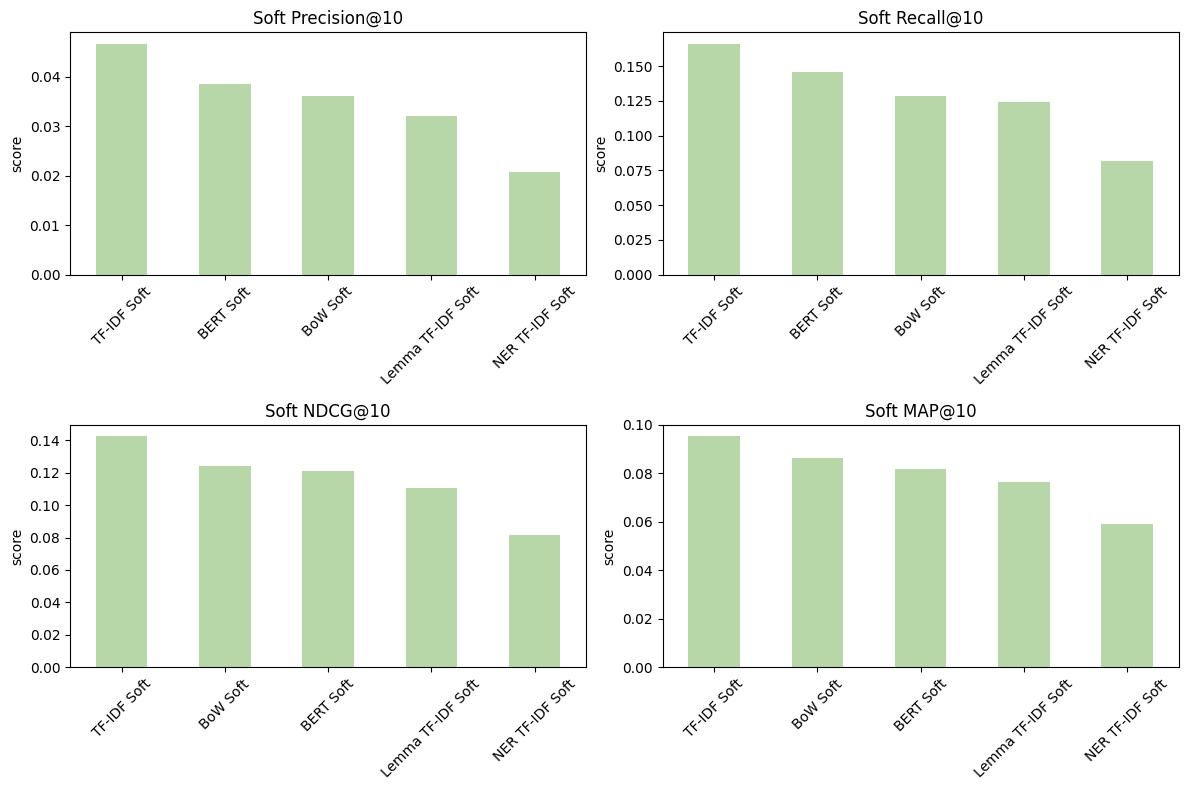

In [28]:
soft_plot_metrics = [metric for metric in ["Precision@10", "Recall@10", "NDCG@10", "MAP@10"] if metric in soft_common_df.columns]

if soft_plot_metrics:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, metric in zip(axes, soft_plot_metrics):
        soft_common_df[metric].sort_values(ascending=False).plot(kind="bar", ax=ax, color="#b7d7a8")
        ax.set_title(f"Soft {metric}")
        ax.set_xlabel("")
        ax.set_ylabel("score")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(soft_plot_metrics):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No soft summary files found yet. Run the soft evaluation cells in the user-to-item notebooks first.")

The results of the soft evaluation show that overall the models performed much better when we take into account the metadata other than the WineID. The TF-IDF still wins in terms of all the metrics, followed by Bag of Words and BERT which alter in the second and third place depending on the metric, while the lemmatized and NER TF-IDF performed a little worse and ended up in the 4th and 5th place.